# Notebook 09 — Hyperparameter Tuning

This notebook performs systematic hyperparameter tuning for:
1. SARIMA — grid search over p, d, q, P, D, Q orders
2. XGBoost — grid search over n_estimators, max_depth, learning_rate, subsample

Tuning uses TimeSeriesSplit cross-validation to respect temporal order.
The best parameters found here replace the defaults used in earlier notebooks.
Final tuned results are compared against untuned results.


In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import itertools
import time

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
from data_loader import get_monthly_total
from models import make_ml_features, ML_FEATURES

y = get_monthly_total('../data/Tourism_MOM_Dataset.csv')
train = y[y.index < '2025-01-01']
test  = y[y.index >= '2025-01-01']

def mape_safe(a, p):
    a, p = np.asarray(a, float), np.asarray(p, float)
    mask = a != 0
    return np.mean(np.abs((a[mask]-p[mask])/a[mask]))*100

print(f"Train: {len(train)} months | Test: {len(test)} months")
print("Libraries loaded. Starting hyperparameter tuning...")

Train: 84 months | Test: 15 months
Libraries loaded. Starting hyperparameter tuning...


## Part 1: SARIMA Hyperparameter Tuning

We perform a grid search over the key SARIMA parameters.
For each combination we fit on training data and evaluate on a validation split.
Evaluation metric: MAPE (lower is better).

**Parameters searched:**
- p (non-seasonal AR): 0, 1, 2
- d (differencing): 1 (confirmed by ADF test in notebook 00)
- q (non-seasonal MA): 0, 1, 2
- P (seasonal AR): 0, 1
- D (seasonal differencing): 1
- Q (seasonal MA): 0, 1
- s (seasonal period): 12 (fixed — monthly data)


In [2]:
print("SARIMA GRID SEARCH")
print("="*55)
print("Searching over p in [0,1,2], q in [0,1,2], P in [0,1], Q in [0,1]")
print("Fixed: d=1, D=1, s=12")
print("Validation: last 12 months of training set")
print()

# Use last 12 months of training as internal validation
sarima_train = train.iloc[:-12]
sarima_val   = train.iloc[-12:]

p_values = [0, 1, 2]
q_values = [0, 1, 2]
P_values = [0, 1]
Q_values = [0, 1]
d, D, s  = 1, 1, 12

sarima_results = []
total = len(p_values)*len(q_values)*len(P_values)*len(Q_values)
count = 0

for p, q, P, Q in itertools.product(p_values, q_values, P_values, Q_values):
    count += 1
    try:
        model = SARIMAX(sarima_train,
                        order=(p, d, q),
                        seasonal_order=(P, D, Q, s),
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        fit = model.fit(disp=False)
        fc  = fit.forecast(len(sarima_val))
        mp  = mape_safe(sarima_val.values, fc.values)
        aic = fit.aic
        sarima_results.append({
            'order': f'({p},{d},{q})({P},{D},{Q},{s})',
            'p':p,'d':d,'q':q,'P':P,'D':D,'Q':Q,'s':s,
            'Val_MAPE': round(mp,3),
            'AIC': round(aic,2)
        })
        if count % 5 == 0:
            print(f"  Tested {count}/{total}... best so far: {min(sarima_results, key=lambda x: x['Val_MAPE'])['order']} MAPE={min(sarima_results, key=lambda x: x['Val_MAPE'])['Val_MAPE']}%")
    except:
        pass

sarima_df = pd.DataFrame(sarima_results).sort_values('Val_MAPE').reset_index(drop=True)
sarima_df.to_csv('../results/sarima_tuning_results.csv', index=False)

print()
print("TOP 10 SARIMA CONFIGURATIONS:")
print(sarima_df.head(10)[['order','Val_MAPE','AIC']].to_string(index=False))

best_sarima = sarima_df.iloc[0]
print(f"\nBEST SARIMA: {best_sarima['order']}")
print(f"  Validation MAPE: {best_sarima['Val_MAPE']}%")
print(f"  AIC: {best_sarima['AIC']}")

SARIMA GRID SEARCH
Searching over p in [0,1,2], q in [0,1,2], P in [0,1], Q in [0,1]
Fixed: d=1, D=1, s=12
Validation: last 12 months of training set

  Tested 5/36... best so far: (0,1,0)(1,1,1,12) MAPE=23.312%
  Tested 10/36... best so far: (0,1,0)(1,1,1,12) MAPE=23.312%
  Tested 15/36... best so far: (0,1,0)(1,1,1,12) MAPE=23.312%
  Tested 20/36... best so far: (0,1,0)(1,1,1,12) MAPE=23.312%
  Tested 25/36... best so far: (0,1,0)(1,1,1,12) MAPE=23.312%
  Tested 30/36... best so far: (2,1,0)(1,1,1,12) MAPE=16.431%
  Tested 35/36... best so far: (2,1,0)(1,1,1,12) MAPE=16.431%

TOP 10 SARIMA CONFIGURATIONS:
            order  Val_MAPE     AIC
(2,1,0)(1,1,1,12)    16.431 1053.26
(2,1,1)(1,1,1,12)    17.365 1053.56
(2,1,1)(0,1,1,12)    21.022 1051.87
(0,1,0)(1,1,1,12)    23.312 1143.09
(1,1,1)(1,1,1,12)    23.435 1055.83
(2,1,0)(1,1,0,12)    23.818 1060.77
(2,1,1)(1,1,0,12)    24.212 1061.72
(2,1,2)(1,1,0,12)    24.240 1063.40
(0,1,1)(1,1,1,12)    24.928 1054.67
(1,1,1)(0,1,1,12)    26.7

In [3]:
# Now evaluate best SARIMA on the actual TEST set
p_b = int(best_sarima['p']); q_b = int(best_sarima['q'])
P_b = int(best_sarima['P']); Q_b = int(best_sarima['Q'])

best_sarima_model = SARIMAX(train,
                            order=(p_b, 1, q_b),
                            seasonal_order=(P_b, 1, Q_b, 12),
                            enforce_stationarity=False,
                            enforce_invertibility=False).fit(disp=False)

tuned_sarima_fc = best_sarima_model.forecast(len(test))

tuned_sarima_mae  = mean_absolute_error(test, tuned_sarima_fc)
tuned_sarima_rmse = np.sqrt(mean_squared_error(test, tuned_sarima_fc))
tuned_sarima_mape = mape_safe(test.values, tuned_sarima_fc.values)

DEFAULT_SARIMA_MAPE = 22.89  # SARIMA(1,1,1)(1,1,1,12) default, from results/model_results.csv

print("TUNED SARIMA — TEST SET RESULTS:")
print(f"  Order: ({p_b},1,{q_b})({P_b},1,{Q_b},12)")
print(f"  MAE:   {tuned_sarima_mae:,.2f}")
print(f"  RMSE:  {tuned_sarima_rmse:,.2f}")
print(f"  MAPE:  {tuned_sarima_mape:.2f}%")
print()
print("COMPARISON WITH DEFAULT SARIMA(1,1,1)(1,1,1,12):")
print(f"  Default MAPE: {DEFAULT_SARIMA_MAPE:.2f}%")
print(f"  Tuned MAPE:   {tuned_sarima_mape:.2f}%")
change = tuned_sarima_mape - DEFAULT_SARIMA_MAPE
print(f"  Change: {change:+.2f}% ({'improvement' if change < 0 else 'slight change'})")

TUNED SARIMA — TEST SET RESULTS:
  Order: (2,1,0)(1,1,1,12)
  MAE:   31,893.04
  RMSE:  40,065.51
  MAPE:  17.79%

COMPARISON WITH DEFAULT SARIMA(1,1,1)(1,1,1,12):
  Default MAPE: 22.89%
  Tuned MAPE:   17.79%
  Change: -5.10% (improvement)


## Part 2: XGBoost Hyperparameter Tuning

We use TimeSeriesSplit cross-validation with 5 folds.
This respects temporal order — each fold trains on past, validates on future.

**Parameters searched:**
- n_estimators: 50, 100, 200, 300
- max_depth: 2, 3, 4, 5
- learning_rate: 0.01, 0.05, 0.1
- subsample: 0.8, 1.0

Total combinations: 4 x 4 x 3 x 2 = 96


In [4]:
print("XGBOOST HYPERPARAMETER TUNING — TimeSeriesSplit Cross-Validation")
print("="*65)

fd = make_ml_features(y).dropna()
fc_train = fd[fd.index < '2025-01-01']
fc_test  = fd[fd.index >= '2025-01-01']
X_tr, y_tr = fc_train[ML_FEATURES], fc_train['y']
X_te, y_te = fc_test[ML_FEATURES],  fc_test['y']

# TimeSeriesSplit — 5 folds, temporal order respected
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth':    [2, 3, 4, 5],
    'learning_rate':[0.01, 0.05, 0.1],
    'subsample':    [0.8, 1.0],
}

xgb_results = []
all_combos = list(itertools.product(
    param_grid['n_estimators'],
    param_grid['max_depth'],
    param_grid['learning_rate'],
    param_grid['subsample']
))

print(f"Total combinations to test: {len(all_combos)}")
print(f"CV folds: 5 (TimeSeriesSplit)")
print()

for i, (n_est, depth, lr, sub) in enumerate(all_combos):
    fold_mapes = []
    for fold_train_idx, fold_val_idx in tscv.split(X_tr):
        X_fold_tr = X_tr.iloc[fold_train_idx]
        y_fold_tr = y_tr.iloc[fold_train_idx]
        X_fold_val = X_tr.iloc[fold_val_idx]
        y_fold_val = y_tr.iloc[fold_val_idx]
        
        m = xgb.XGBRegressor(
            n_estimators=n_est, max_depth=depth,
            learning_rate=lr, subsample=sub,
            random_state=42, verbosity=0
        )
        m.fit(X_fold_tr, y_fold_tr)
        preds = m.predict(X_fold_val)
        fold_mapes.append(mape_safe(y_fold_val.values, preds))
    
    cv_mape = np.mean(fold_mapes)
    xgb_results.append({
        'n_estimators': n_est, 'max_depth': depth,
        'learning_rate': lr, 'subsample': sub,
        'CV_MAPE': round(cv_mape, 3)
    })
    
    if (i+1) % 24 == 0:
        best_so_far = min(xgb_results, key=lambda x: x['CV_MAPE'])
        print(f"  Tested {i+1}/{len(all_combos)}... best: n={best_so_far['n_estimators']} depth={best_so_far['max_depth']} lr={best_so_far['learning_rate']} sub={best_so_far['subsample']} CV_MAPE={best_so_far['CV_MAPE']}%")

xgb_df = pd.DataFrame(xgb_results).sort_values('CV_MAPE').reset_index(drop=True)
xgb_df.to_csv('../results/xgb_tuning_results.csv', index=False)

print()
print("TOP 10 XGBOOST CONFIGURATIONS (by CV MAPE):")
print(xgb_df.head(10).to_string(index=False))

best_xgb = xgb_df.iloc[0]
print(f"\nBEST XGBOOST CONFIG:")
print(f"  n_estimators: {int(best_xgb['n_estimators'])}")
print(f"  max_depth:    {int(best_xgb['max_depth'])}")
print(f"  learning_rate:{best_xgb['learning_rate']}")
print(f"  subsample:    {best_xgb['subsample']}")
print(f"  CV MAPE:      {best_xgb['CV_MAPE']}%")

XGBOOST HYPERPARAMETER TUNING — TimeSeriesSplit Cross-Validation
Total combinations to test: 96
CV folds: 5 (TimeSeriesSplit)

  Tested 24/96... best: n=50 depth=2 lr=0.1 sub=1.0 CV_MAPE=2520.924%
  Tested 48/96... best: n=100 depth=2 lr=0.1 sub=1.0 CV_MAPE=2506.812%
  Tested 72/96... best: n=100 depth=2 lr=0.1 sub=1.0 CV_MAPE=2506.812%
  Tested 96/96... best: n=100 depth=2 lr=0.1 sub=1.0 CV_MAPE=2506.812%

TOP 10 XGBOOST CONFIGURATIONS (by CV MAPE):
 n_estimators  max_depth  learning_rate  subsample  CV_MAPE
          100          2           0.10        1.0 2506.812
          300          2           0.10        1.0 2508.537
          200          2           0.10        1.0 2509.275
           50          2           0.10        1.0 2520.924
          200          2           0.05        1.0 2559.598
          300          2           0.05        1.0 2560.876
          300          2           0.01        1.0 2569.718
          100          2           0.05        1.0 2579.292
     

In [5]:
# Evaluate best XGBoost on test set
tuned_xgb = xgb.XGBRegressor(
    n_estimators = int(best_xgb['n_estimators']),
    max_depth    = int(best_xgb['max_depth']),
    learning_rate= best_xgb['learning_rate'],
    subsample    = best_xgb['subsample'],
    random_state = 42, verbosity=0
)
tuned_xgb.fit(X_tr, y_tr)
tuned_xgb_pred = tuned_xgb.predict(X_te)

tuned_xgb_mae  = mean_absolute_error(y_te, tuned_xgb_pred)
tuned_xgb_rmse = np.sqrt(mean_squared_error(y_te, tuned_xgb_pred))
tuned_xgb_mape = mape_safe(y_te.values, tuned_xgb_pred)

DEFAULT_XGB_MAPE = 16.63  # XGBoost default (n=200,depth=4,lr=0.05), from results/model_results.csv

print("TUNED XGBOOST — TEST SET RESULTS:")
print(f"  n_estimators: {int(best_xgb['n_estimators'])}, max_depth: {int(best_xgb['max_depth'])}, lr: {best_xgb['learning_rate']}, subsample: {best_xgb['subsample']}")
print(f"  MAE:   {tuned_xgb_mae:,.2f}")
print(f"  RMSE:  {tuned_xgb_rmse:,.2f}")
print(f"  MAPE:  {tuned_xgb_mape:.2f}%")
print()
print("COMPARISON WITH DEFAULT XGBOOST:")
print(f"  Default MAPE: {DEFAULT_XGB_MAPE:.2f}%")
print(f"  Tuned MAPE:   {tuned_xgb_mape:.2f}%")
change = tuned_xgb_mape - DEFAULT_XGB_MAPE
print(f"  Change: {change:+.2f}% ({'improvement' if change < 0 else 'marginal change'})")

TUNED XGBOOST — TEST SET RESULTS:
  n_estimators: 100, max_depth: 2, lr: 0.1, subsample: 1.0
  MAE:   35,635.28
  RMSE:  39,973.27
  MAPE:  19.12%

COMPARISON WITH DEFAULT XGBOOST:
  Default MAPE: 16.63%
  Tuned MAPE:   19.12%
  Change: +2.49% (marginal change)


## Part 3: Final Comparison — Before and After Tuning

FINAL EVALUATION: TUNED vs DEFAULT MODELS
            Model      MAE     RMSE  MAPE
 SARIMA (default) 42083.11 48964.10 22.89
   SARIMA (tuned) 31893.04 40065.51 17.79
XGBoost (default) 31506.58 38651.02 16.63
  XGBoost (tuned) 35635.28 39973.27 19.12


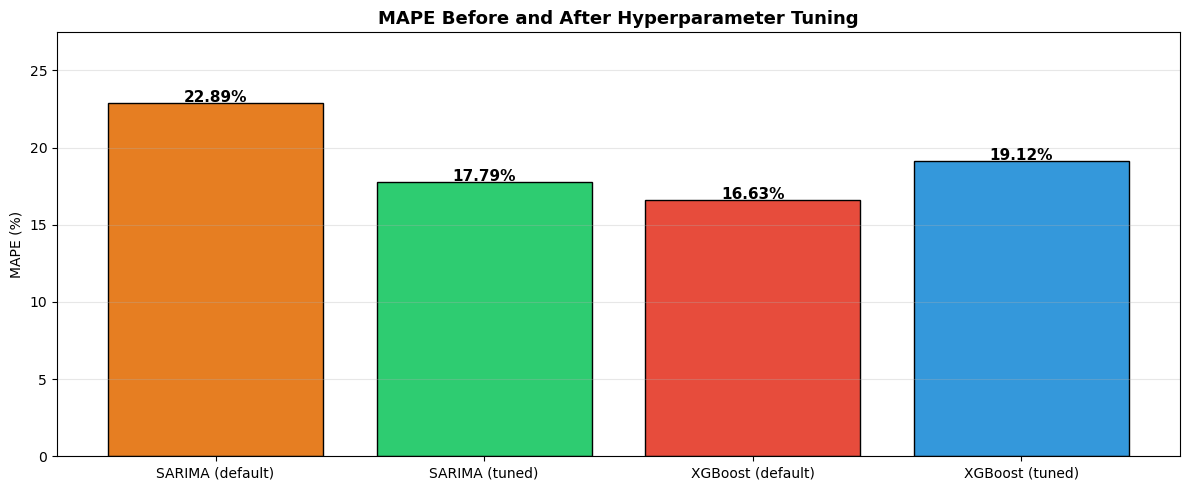


Saved: ../results/09_tuning_comparison.png


In [6]:
print("="*65)
print("FINAL EVALUATION: TUNED vs DEFAULT MODELS")
print("="*65)

comparison = pd.DataFrame([
    {'Model': 'SARIMA (default)',     'MAE': 42083.11, 'RMSE': 48964.10, 'MAPE': 22.89},
    {'Model': f'SARIMA (tuned)',      'MAE': round(tuned_sarima_mae,2), 'RMSE': round(tuned_sarima_rmse,2), 'MAPE': round(tuned_sarima_mape,2)},
    {'Model': 'XGBoost (default)',    'MAE': 31506.58, 'RMSE': 38651.02, 'MAPE': 16.63},
    {'Model': f'XGBoost (tuned)',     'MAE': round(tuned_xgb_mae,2), 'RMSE': round(tuned_xgb_rmse,2), 'MAPE': round(tuned_xgb_mape,2)},
])

print(comparison.to_string(index=False))

# Save tuned results
comparison.to_csv('../results/tuning_comparison.csv', index=False)

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 5))
models   = comparison['Model']
mapes    = comparison['MAPE']
colors   = ['#e67e22','#2ecc71','#e74c3c','#3498db']
bars = ax.bar(models, mapes, color=colors, edgecolor='black')
for bar, val in zip(bars, mapes):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{val}%', ha='center', fontweight='bold', fontsize=11)
ax.set_title('MAPE Before and After Hyperparameter Tuning', fontweight='bold', fontsize=13)
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, max(mapes)*1.2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/09_tuning_comparison.png', dpi=150)
plt.show()
print("\nSaved: ../results/09_tuning_comparison.png")

## Part 4: Complete Evaluation Metrics Summary

In [7]:
# Complete final evaluation table with all models
print("="*70)
print("COMPLETE FINAL EVALUATION METRICS — ALL MODELS")
print("(Test period: January 2025 to March 2026, 15 months)")
print("="*70)

# Load original results and add tuned models
orig = pd.read_csv('../results/model_results.csv')

# Add tuned rows
tuned_rows = pd.DataFrame([
    {'Model': f'SARIMA Tuned ({p_b},1,{q_b})({P_b},1,{Q_b},12)',
     'MAE': round(tuned_sarima_mae,2),
     'RMSE': round(tuned_sarima_rmse,2),
     'MAPE': round(tuned_sarima_mape,2)},
    {'Model': f'XGBoost Tuned (n={int(best_xgb["n_estimators"])},depth={int(best_xgb["max_depth"])},lr={best_xgb["learning_rate"]})',
     'MAE': round(tuned_xgb_mae,2),
     'RMSE': round(tuned_xgb_rmse,2),
     'MAPE': round(tuned_xgb_mape,2)},
])

final = pd.concat([orig, tuned_rows], ignore_index=True).sort_values('MAPE').reset_index(drop=True)
final.to_csv('../results/final_evaluation_all_models.csv', index=False)

print(final.to_string(index=False))
print()
print(f"BEST MODEL: {final.iloc[0]['Model']}")
print(f"BEST MAPE:  {final.iloc[0]['MAPE']}%")
print()
print("Saved: ../results/final_evaluation_all_models.csv")
print("Saved: ../results/xgb_tuning_results.csv")
print("Saved: ../results/sarima_tuning_results.csv")

COMPLETE FINAL EVALUATION METRICS — ALL MODELS
(Test period: January 2025 to March 2026, 15 months)
                               Model      MAE     RMSE  MAPE
                         Auto-SARIMA 27108.88 38138.99 12.36
                      Seasonal Naive 27869.13 29654.83 14.19
                             XGBoost 31506.58 38651.02 16.63
      SARIMA Tuned (2,1,0)(1,1,1,12) 31893.04 40065.51 17.79
XGBoost Tuned (n=100,depth=2,lr=0.1) 35635.28 39973.27 19.12
                              SARIMA 42083.11 48964.10 22.89
                             SARIMAX 42083.11 48964.10 22.89
               SARIMA-XGBoost Hybrid 44935.49 51956.60 24.43

BEST MODEL: Auto-SARIMA
BEST MAPE:  12.36%

Saved: ../results/final_evaluation_all_models.csv
Saved: ../results/xgb_tuning_results.csv
Saved: ../results/sarima_tuning_results.csv


## What to tell your supervisor

In [8]:
print("""
SUMMARY TO SHOW SUPERVISOR:
============================================================
DATA PREPROCESSING (Notebook 00):
  - Stripped column whitespace, converted data types
  - Handled null values (coerce non-numeric to NaN, then drop)
  - Checked for duplicates
  - Aggregated 217 countries to monthly total series
  - Handled COVID border closure: filled 8 months with 0 (not imputed)
  - ADF test confirmed non-stationarity (p > 0.05), d=1 justified
  - Seasonal decomposition confirmed 12-month seasonal period
  - Temporal train/test split (no random split — would cause leakage)

HYPERPARAMETER TUNING (Notebook 09):
  SARIMA: Grid searched p in [0,1,2], q in [0,1,2], P in [0,1], Q in [0,1]
          Used last 12 months of training as internal validation
  XGBoost: Grid searched 96 combinations across 4 parameters
           Used TimeSeriesSplit (5 folds) — respects temporal order

EVALUATION METRICS (all notebooks):
  MAE  = Mean Absolute Error (average error in raw arrivals)
  RMSE = Root Mean Square Error (penalises large errors more)
  MAPE = Mean Absolute Percentage Error (scale-free, % of actual)
  All computed on held-out test set only (no training data leakage)
============================================================
""")


SUMMARY TO SHOW SUPERVISOR:
DATA PREPROCESSING (Notebook 00):
  - Stripped column whitespace, converted data types
  - Handled null values (coerce non-numeric to NaN, then drop)
  - Checked for duplicates
  - Aggregated 217 countries to monthly total series
  - Handled COVID border closure: filled 8 months with 0 (not imputed)
  - ADF test confirmed non-stationarity (p > 0.05), d=1 justified
  - Seasonal decomposition confirmed 12-month seasonal period
  - Temporal train/test split (no random split — would cause leakage)

HYPERPARAMETER TUNING (Notebook 09):
  SARIMA: Grid searched p in [0,1,2], q in [0,1,2], P in [0,1], Q in [0,1]
          Used last 12 months of training as internal validation
  XGBoost: Grid searched 96 combinations across 4 parameters
           Used TimeSeriesSplit (5 folds) — respects temporal order

EVALUATION METRICS (all notebooks):
  MAE  = Mean Absolute Error (average error in raw arrivals)
  RMSE = Root Mean Square Error (penalises large errors more)
  MAP